# EDA and Regression Modeling of NBA Player Salaries Based on Player Performances

## Project Setup

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

Data References:

Kadam, N., Shakir, Y.H., Patel, R., Tripathi, S., hoon0303, Kanchana1990, Mahmoud, K., Beto, Zahran, S., Shadab, M., Lukhi, L. (2026).
<ul style="list-style-type: none; padding-left: 20px;">
  <li> <i>NBA Player Stats Dataset 2026</i> (Version 1) [Data set]. Kaggle. <a href="https://www.kaggle.com/datasets/nilesh2042/nba-player-stats-2026">https://www.kaggle.com/datasets/nilesh2042/nba-player-stats-2026</a></li>
</ul>

Basketball Reference. (2026). *2025-26 NBA Player Contracts* [Data set]. https://www.basketball-reference.com/contracts/players.html

Some minor changes were made to player names in both datasets to resolve formatting differences (i.e. Dončić vs Doncic).

In [2]:
#https://www.kaggle.com/datasets/nilesh2042/nba-player-stats-2026
stats_df = pd.read_csv('Datasets/nba_player_stats_2026.csv')
#https://www.basketball-reference.com/contracts/players.html
salary_df = pd.read_csv('Datasets/nba_salary_25-26.csv')

## Data Preparation

To begin, I have displayed the size of each dataset as well as the heads to understand the general layout of the data. 

In [3]:
print("Stats DF Shape: ", stats_df.shape, "Salary DF Shape: ", salary_df.shape)

display(stats_df.head(n=5))
display(salary_df.head(n=5))

Stats DF Shape:  (582, 28) Salary DF Shape:  (530, 10)


,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,254,694,0.366,503,645,0.780,41,454,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,115,298,0.386,540,614,0.879,38,254,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,140,404,0.347,426,536,0.795,81,411,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,186,450,0.413,408,467,0.874,41,385,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,220,599,0.367,372,417,0.892,24,266,290,461,130,55,171,151,1980,1893,2.70,0.76


,Rk,Player,Tm,2025-26,2026-27,2027-28,2028-29,2029-30,2030-31,Guaranteed
0,1,Stephen Curry,GSW,"$59,606,817","$62,587,158",NaN,NaN,NaN,NaN,"$122,193,975"
1,2,Joel Embiid,PHI,"$55,224,526","$58,100,000","$62,748,000","$67,396,000",NaN,NaN,"$176,072,526"
2,3,Nikola Jokić,DEN,"$55,224,526","$59,033,114","$62,841,702",NaN,NaN,NaN,"$114,257,640"
3,4,Kevin Durant,HOU,"$54,708,609","$43,902,439","$46,097,561",NaN,NaN,NaN,"$98,611,048"
4,5,Jayson Tatum,BOS,"$54,126,450","$58,456,566","$62,786,682","$67,116,798","$71,446,914",NaN,"$242,486,496"


I cleaned the data by dropping duplicate players from the salary data that occurred when players moved between teams mid-season, such as in trades and kept the most recent contract that was placed below the old contract. I dropped columns including the player salaries in future contract years and removed the few players who were missing salary information. Finally, I reformatted salary dataset as an integer from a string.

In [4]:
salary_df.drop_duplicates(subset=['Player'], keep='last', inplace=True)
salary_df.drop(columns=['2026-27', '2027-28', '2028-29', '2029-30', '2030-31'], inplace=True)

salary_df.dropna(subset=['2025-26'], inplace=True)

salary_df['2025-26'] = salary_df['2025-26'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)

From the player statistics dataframe, I removed unneccessary columns like team names and the dataset's player rank. I then normalized each player stat by and to remove the influence of injuries during the 2025-26 season which could greatly artificially lower player stats but would be unlikely to affect contract value in most cases. I then removed players who did not play a significant number of games or minutes per game.

In [5]:
stats_df.drop(columns=['PLAYER_ID', 'TEAM_ID', 'RANK'], inplace=True)
stats_df['PPG'] = round(stats_df['PTS'] / stats_df['GP'], 1)
stats_df['APG'] = round(stats_df['AST'] / stats_df['GP'], 1)
stats_df['RPG'] = round(stats_df['REB'] / stats_df['GP'], 1)
stats_df['BPG'] = round(stats_df['BLK'] / stats_df['GP'], 1)
stats_df['TPG'] = round(stats_df['TOV'] / stats_df['GP'], 1)
stats_df['SPG'] = round(stats_df['STL'] / stats_df['GP'], 1)
stats_df['MPG'] = round(stats_df['MIN'] / stats_df['GP'], 1)

stats_df.drop(columns=['PTS', 'AST', 'REB', 'BLK', 'TOV', 'STL'], inplace=True)

stats_df = stats_df[(stats_df['GP'] >= 6) & (stats_df['MPG'] >= 4)]

I performed an inner merge to ensure that players with both salary and performance data. This removed players that either did not play at all this season and therefore did not have performance data or players that were on "2-Way" contracts that split time between the NBA and the NBA G League and lacked inclusion in the salary data.

In [6]:
salary_df.rename(columns={'Player':'PLAYER', '2025-26':'Salary 2025-26'}, inplace=True)
df = pd.merge(salary_df, stats_df, on='PLAYER', how='inner')

df.head(n=5)

,Rk,PLAYER,Tm,Salary 2025-26,Guaranteed,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,PF,EFF,AST_TOV,STL_TOV,PPG,APG,RPG,BPG,TPG,SPG,MPG
0,1,Stephen Curry,GSW,59606817,"$122,193,975",GSW,43,1329,374,799,0.468,190,484,0.393,204,221,0.923,17,137,75,1002,1.68,0.41,26.6,4.7,3.6,0.4,2.8,1.1,30.9
1,2,Joel Embiid,PHI,55224526,"$176,072,526",PHI,38,1201,341,697,0.489,53,159,0.333,286,335,0.854,75,218,82,1017,1.38,0.19,26.9,3.9,7.7,1.2,2.9,0.6,31.6
2,3,Nikola Jokić,DEN,55224526,"$114,257,640",DEN,65,2265,644,1132,0.569,112,295,0.380,399,480,0.831,192,644,173,2665,2.87,0.38,27.7,10.7,12.9,0.8,3.7,1.4,34.8
3,4,Kevin Durant,HOU,54708609,"$98,611,048",HOU,78,2840,716,1376,0.520,186,450,0.413,408,467,0.874,41,385,142,1992,1.51,0.25,26.0,4.8,5.5,0.9,3.2,0.8,36.4
4,5,Jayson Tatum,BOS,54126450,"$242,486,496",BOS,16,522,118,287,0.411,47,143,0.329,65,79,0.823,8,152,26,396,2.18,0.56,21.8,5.3,10.0,0.2,2.4,1.4,32.6


## Exploratory Data Analysis

I computed the player salary quartiles and made a density plot of salaries to get a general understanding of the salary distribution. This distribution is skewed right with the majority of salaries falling below \\$10 million and a relatively small portion of salaries above \\$20 million.

Salary Quartiles:
 0.25     2298930.5
0.50     6045000.0
0.75    15000000.0
Name: Salary 2025-26, dtype: float64


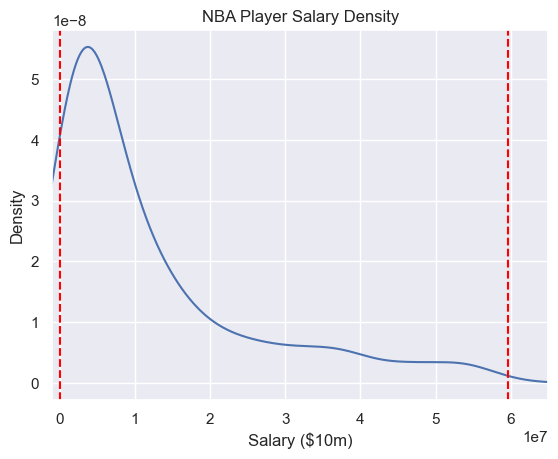

In [7]:
quartiles = df['Salary 2025-26'].quantile([0.25, 0.5, 0.75])
print("Salary Quartiles:\n", quartiles)

ax = df['Salary 2025-26'].plot.kde(title='NBA Player Salary Density')
ax.set_xlabel("Salary ($10m)")
ax.axvline(min(df['Salary 2025-26']), color='red', linestyle='--', label=f'Min: {min(df['Salary 2025-26'])}')
ax.axvline(max(df['Salary 2025-26']), color='red', linestyle='--', label=f'Max: {max(df['Salary 2025-26'])}')
ax.set_xlim(-1000000, 65000000)
plt.show()

I also made a set of density plots for the offensive and defensive performance stats to understand the distributions of player metrics. The distributions for each stat vary in spread but are all generally unimodal. Most of the distributions are skewed right like the salary distribution, but free throw percentage and three point percentage are slightly skewed left.

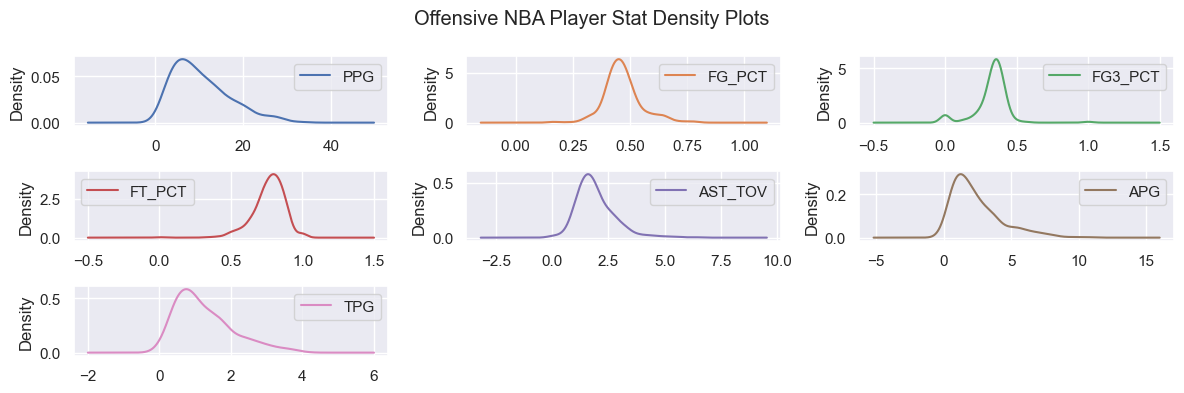

In [8]:
offense_df = df[['PPG', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'AST_TOV', 'APG', 'TPG']]

offense_df.plot(kind='density', subplots=True, layout=(3,3), sharex=False, figsize=(12,4), title='Offensive NBA Player Stat Density Plots')
plt.tight_layout()
plt.show()

Similar to the offensive distributions, the distributions of defensive stats vary noticeably. Rebounds per game and steals per game have relatively wide distributions while steal-turnover ratio and blocks per game have much tighter distributions. 

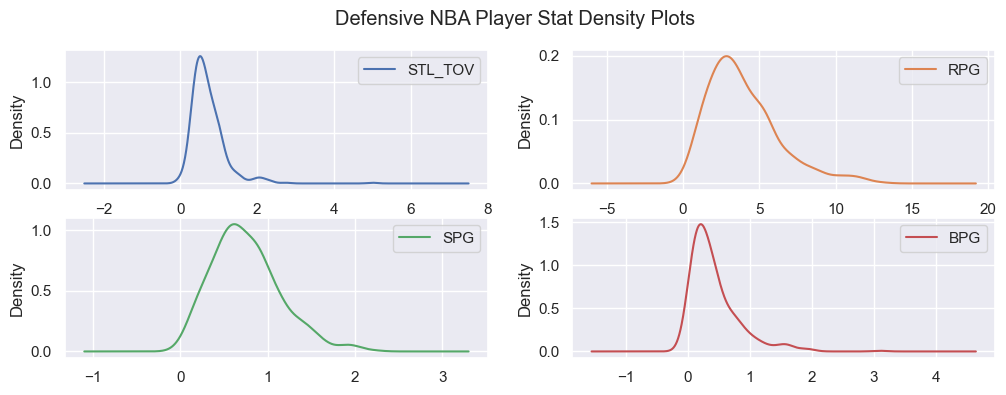

In [9]:
defense_df = df[['STL_TOV', 'RPG', 'SPG', 'BPG']]

defense_df.plot(kind='density', subplots=True, layout=(2,2), sharex=False, figsize=(12,4), title='Defensive NBA Player Stat Density Plots')
plt.show()

My next step was to plot the interactions between player salaries and different variables that I predicted would be important for estimating player salary. Based on the scatter plots, points per game has the strongest correlation with player salary. Rebounds per game and steals per game look to have a weak corrlation with salary while 3pt percentage, assist-turnover ratio, and blocks per game do not look to have a significant connection to player salary.

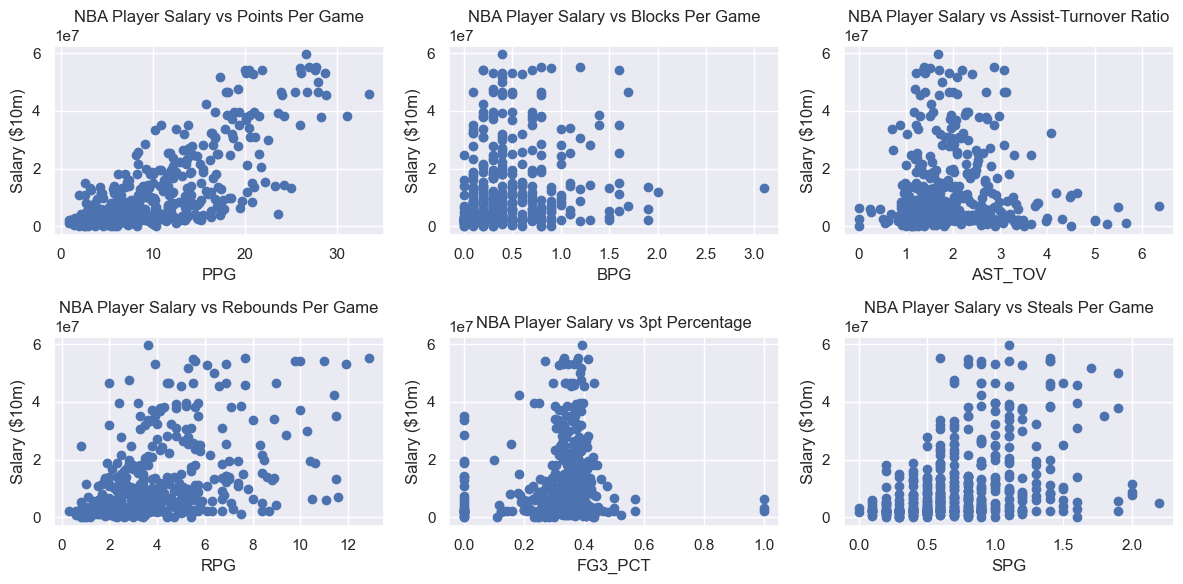

In [10]:
fig, axes = plt.subplots(2,3,figsize=(12,6))
(ax1, ax2, ax3, ax4, ax5, ax6) = axes.flatten()

ax1.scatter(x=df['PPG'], y=df['Salary 2025-26'])
ax1.set_title('NBA Player Salary vs Points Per Game')
ax1.set_ylabel('Salary ($10m)')
ax1.set_xlabel('PPG')

ax2.scatter(x=df['BPG'], y=df['Salary 2025-26'])
ax2.set_title('NBA Player Salary vs Blocks Per Game')
ax2.set_ylabel('Salary ($10m)')
ax2.set_xlabel('BPG')

ax3.scatter(x=df['AST_TOV'], y=df['Salary 2025-26'])
ax3.set_title('NBA Player Salary vs Assist-Turnover Ratio')
ax3.set_ylabel('Salary ($10m)')
ax3.set_xlabel('AST_TOV')

ax4.scatter(x=df['RPG'], y=df['Salary 2025-26'])
ax4.set_title('NBA Player Salary vs Rebounds Per Game')
ax4.set_ylabel('Salary ($10m)')
ax4.set_xlabel('RPG')

ax5.scatter(x=df['FG3_PCT'], y=df['Salary 2025-26'])
ax5.set_title('NBA Player Salary vs 3pt Percentage')
ax5.set_ylabel('Salary ($10m)')
ax5.set_xlabel('FG3_PCT')

ax6.scatter(x=df['SPG'], y=df['Salary 2025-26'])
ax6.set_title('NBA Player Salary vs Steals Per Game')
ax6.set_ylabel('Salary ($10m)')
ax6.set_xlabel('SPG')

plt.tight_layout()
plt.show()

I made a correlation heatmap with seaborn to visualize the interactions between variables. I was particularly interested in how other variables are correlated with salary. The metrics that proved to be most correlated with a player's salary were minutes per game, assists per game, rebounds per game, steals per game, and especially points per game. Blocks per game are seemingly valued less than these other stats, as they had only roughly half as high of a correlation with salary compared to metrics like steals or rebounds per game. This heatmap also shows some other notable correlations, such as the strong correlation between minutes per game and other game-level stats such as points per game.

<Axes: >

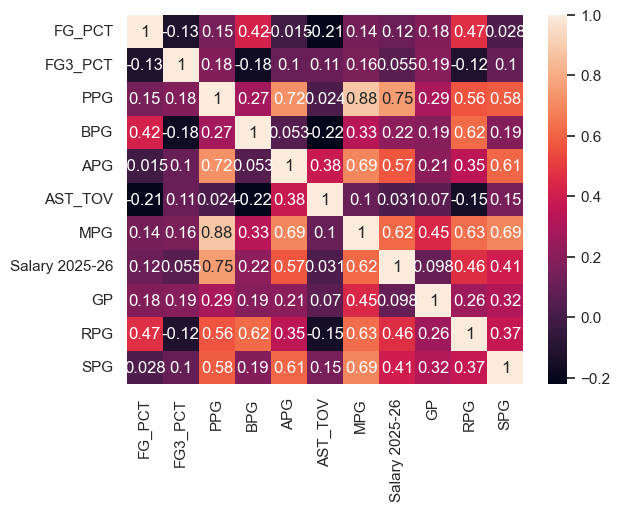

In [11]:
df_corr = df[['FG_PCT', 'FG3_PCT', 'PPG', 'BPG', 'APG', 'AST_TOV', 'MPG', 'Salary 2025-26', 'GP', 'RPG', 'SPG']].corr()
sns.heatmap(df_corr, annot=True)

## Estimation/ Regression Modeling

I used the player performance metrics to create a multiple linear regression model with scikit-learn for a player's salary. After experimenting to find some unhelpful variables, I removed stats which were not formatted as ratios, which gave usable results. This model had an adjusted R^2 value of around 0.521 and an RMSE of about $8836562.

In [12]:
X = df.drop(columns=['Rk','PLAYER', 'Tm', 'TEAM', 'Salary 2025-26', 'Guaranteed', 'MIN', 'OREB', 'DREB'])
y = np.array(df['Salary 2025-26']).reshape(-1, 1)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = 0.25, train_size = 0.75, random_state=30)

model1 = sklearn.linear_model.LinearRegression()
model1.fit(X_train,y_train)
salary_pred1 = model1.predict(X_test)

In [13]:
r2 = model1.score(X_test, y_test)
n=len(X_train)
p = len(X.columns)

adj_r2 = 1-((1-r2) * (n-1))/(n-p-1)
print(f"Adj. R^2: {adj_r2}")

Adj. R^2: 0.5212435460476312


In [14]:
rmse = int(sklearn.metrics.root_mean_squared_error(y_test, salary_pred1))
print(f"RMSE: ${rmse}")

RMSE: $8836562


In [15]:
print(int(model1.intercept_[0]))
pd.Series(model1.coef_.flatten(), index=X_train.columns)

7146164


GP         7.707499e+03
FGM        8.289835e+04
FGA       -2.744145e+04
FG_PCT    -1.187904e+07
FG3M       3.471530e+02
FG3A       3.311302e+03
FG3_PCT   -7.716176e+06
FTM       -1.554932e+04
FTA        8.866181e+03
FT_PCT    -3.703755e+06
PF         8.026633e+02
EFF       -1.647765e+04
AST_TOV   -7.739323e+05
STL_TOV    7.095428e+05
PPG        1.976467e+06
APG        2.801674e+06
RPG        1.131783e+06
BPG        2.083292e+06
TPG       -4.826410e+06
SPG        3.880040e+05
MPG       -2.145669e+05
dtype: float64

I also used automated feature selecting to find a model which was slightly more predictive than the model I manually created. I removed the "Guaranteed" and "MIN" columns: Guaranteed was too strongly correlated with salary as a part of the player's contract and not a metric and MIN counted total minutes over the courses of the season and yielded weaker models when the feature selector chose it over MPG. I experimented with a few configurations for the feature selector and landed on 5 features selected in a backwards direction with an adjusted R^2 value of about 0.575 and an RMSE of about $8536050. This model used 3 point percentage, points per game, assists per game, rebounds per game, and minutes per game as predictors of salary.

In [16]:
X = df.drop(columns=['Rk','PLAYER', 'Tm', 'TEAM', 'Salary 2025-26', 'Guaranteed', 'MIN'])
y = np.array(df['Salary 2025-26']).reshape(-1, 1)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = 0.25, train_size = 0.75, random_state=30)

model2 = sklearn.linear_model.LinearRegression()

sfs_forward = sklearn.feature_selection.SequentialFeatureSelector(model2, n_features_to_select=5, direction='backward')
sfs_forward.fit(X_train, y_train)
print(X.columns[sfs_forward.get_support()])

X_train_selected = sfs_forward.transform(X_train)
X_test_selected  = sfs_forward.transform(X_test)

model2.fit(X_train_selected, y_train)

salary_pred2 = model2.predict(X_test_selected)

Index(['FG3_PCT', 'PPG', 'APG', 'RPG', 'MPG'], dtype='str')


In [17]:
r2 = model2.score(X_test_selected, y_test)
n=len(X_train)
p = X_train_selected.shape[1]

adj_r2 = 1-((1-r2) * (n-1))/(n-p-1)
print(f"Adj. R^2: {adj_r2}")

Adj. R^2: 0.5745899672548864


In [18]:
rmse = int(sklearn.metrics.root_mean_squared_error(y_test, salary_pred2))
print(f"RMSE: ${rmse}")

RMSE: $8536050


In [19]:
X = df[['FG3_PCT', 'PPG', 'APG', 'RPG', 'MPG']]
y = np.array(df['Salary 2025-26']).reshape(-1, 1)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = 0.25, train_size = 0.75, random_state=30)

model2 = sklearn.linear_model.LinearRegression()
model2.fit(X_train,y_train)

print(int(model2.intercept_[0]))
pd.Series(model2.coef_.flatten(), index=X_train.columns)

426407


FG3_PCT   -8.428510e+06
PPG        1.788207e+06
APG        5.345804e+05
RPG        5.179613e+05
MPG       -3.399326e+05
dtype: float64

Finally, I created diagnostic plots to check the regression model assumptions. The QQ plot has a strongly linear pattern that indicates that the normality of residuals assumption is clearly met. The constant variance assumption is a bit suspect, as the points at the edges of the residuals vs. fitted plot look to have very slightly less variance than those in the middle and there is a minor funnel shape in the scale-location plot. The linear relationship assumption also looks to be somewhat problematic as there is a gradual but definitely noticeable curve to the points of the residuals vs. fitted plot with higher values to the left and lower values to the right. It is also worth noting that the influence plot shows a few outliers in the data. Finally, the independence of observations assumption is likely not completely met, as players on the same teams will likely have some influence on each others' performances. Overall, while there are definitely some issues with the linear modeling assumptions and a linear model may not be perfect to capture the multifaceted nature of contract value, the issues seem to be minor enough to acceptably model this relationship linearly.

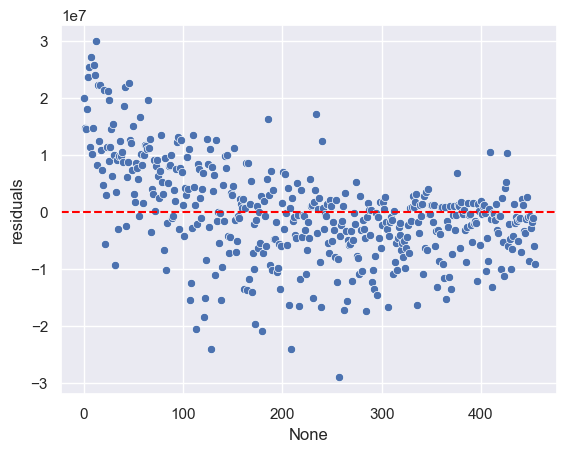

In [20]:
model = smf.ols("Q('Salary 2025-26') ~ FG3_PCT + MPG + PPG", data=df).fit()
df["residuals"] = model.resid

sns.scatterplot(data=df, x=df.index, y="residuals")
plt.axhline(0, color="red", linestyle="--")
plt.show()

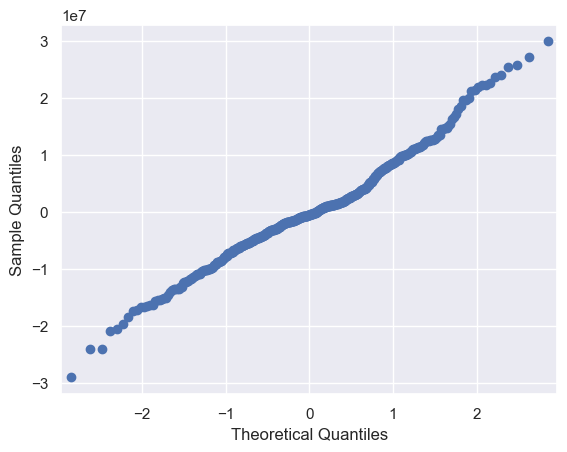

In [21]:
fig = sm.qqplot(df['residuals'])
plt.show()

<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\aiden\AppData\Local\Temp\ipykernel_32556\1904846878.py:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('$\sqrt{|Standardized\ Residuals|}$')


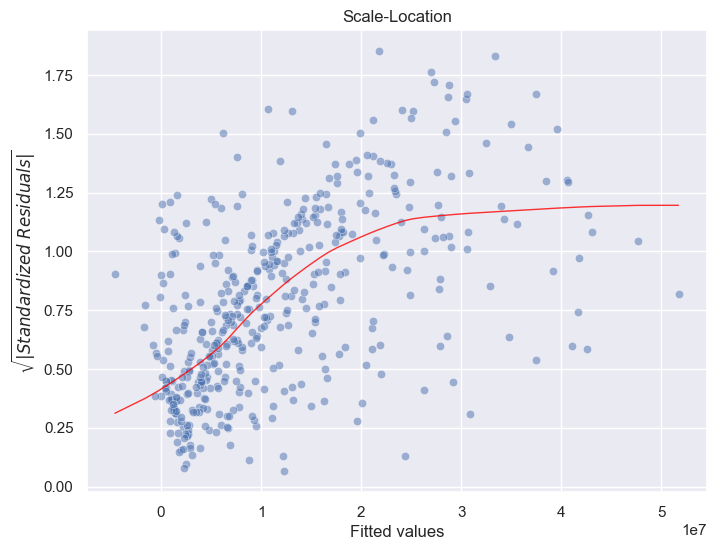

In [22]:
fitted_values = model.fittedvalues

norm_residuals = model.get_influence().resid_studentized_internal
abs_sqrt_norm_residuals = np.sqrt(np.abs(norm_residuals))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=abs_sqrt_norm_residuals, alpha=0.5)
sns.regplot(x=fitted_values, y=abs_sqrt_norm_residuals, 
            scatter=False, ci=False, lowess=True, 
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

plt.title('Scale-Location')
plt.xlabel('Fitted values')
plt.ylabel('$\sqrt{|Standardized\ Residuals|}$')
plt.show()

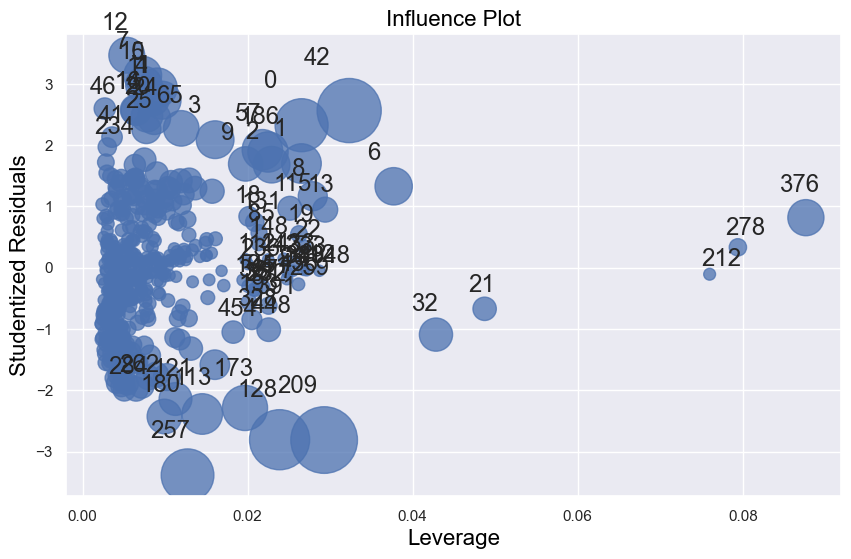

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")

plt.show()


In [24]:
df.shape

(455, 31)

## Conclusion

Intuitively, it makes sense that player performances and player salaries are linked. However, by exploring player data from the 2025-26 NBA season and using regression modeling, I have highlighted the player metrics that have the greatest connection with the players' salaries and have constructed a model to estimate what a player's salary could be based upon their performances.

### Drawbacks of Analysis

 - With a somewhat small total 455 of eligible players for analysis, it was difficult to remove many features from the model without overfitting. The sequential feature selector, for example, chose different features when different random seeds were used. However, there are methods to remedy this such as k-fold cross validation.
 - Players' performances are linked with their team's performances which could greatly alter the relationship between their performance and salary.
 - While the minutes played stat was used in modeling, it could be argued that this is not necessarily a measure of a player's impact on the court and instead is a stat largely controlled by a player's coach. However, it still likely generally reflects a player's importance to their team as more impactful players will likely be given more minutes. This could also help to account for less "measurable" contributions that a player makes to their team.
 - A handful (<20) of players lacked salary data in the contract database.
 - The salary of players on their rookie contracts are based solely on their draft position and not their NBA performances.

### Takeaways

 - The salary distribution was skewed to the right, reflecting that the majority of players make a similar amount, less than \\$10 million per year, while some highly-paid players make almost \\$60 million per year.
 - Points per game is linked much more heavily to a player's salary than any other stat.
 - Games Played, Assist-Turnover Ratio, and 3pt FG Percentage had little correlation with player salary.
 - A small majority of the variation in a player's salary can be explained by using a linear regression model with a player's performance statistics.

---